AI Assignment03 - k232001  
Kaggle Playground Series S6E4



In [1]:
!pip install -q catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

from catboost import CatBoostClassifier

In [5]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train Shape:", train.shape)
print("Test Shape :", test.shape)

train.head()

Train Shape: (630000, 21)
Test Shape : (270000, 20)


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [6]:
target = "Irrigation_Need"

X = train.drop(columns=[target])
y = train[target]

# Save IDs
test_ids = test["id"]

# Combine for encoding consistency
combined = pd.concat([X, test], axis=0)

# Encode object columns
encoders = {}

for col in combined.columns:
    if combined[col].dtype == "object":
        le = LabelEncoder()
        combined[col] = le.fit_transform(combined[col].astype(str))
        encoders[col] = le

# Split back
X = combined.iloc[:len(train), :]
X_test = combined.iloc[len(train):, :]

# Encode target
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [9]:
results = {}

# Decision Tree
dt = DecisionTreeClassifier(max_depth=12, random_state=42)
dt.fit(X_train, y_train)
pred = dt.predict(X_val)
acc = accuracy_score(y_val, pred)
results["Decision Tree"] = acc
print("Decision Tree Accuracy:", acc)

# Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
pred = nb.predict(X_val)
acc = accuracy_score(y_val, pred)
results["Naive Bayes"] = acc
print("Naive Bayes Accuracy:", acc)

# CatBoost
cb = CatBoostClassifier(
    iterations=150,
    depth=6,
    learning_rate=0.1,
    loss_function='MultiClass',
    verbose=0
)

cb.fit(X_train, y_train)
pred = cb.predict(X_val).astype(int).flatten()
acc = accuracy_score(y_val, pred)
results["CatBoost"] = acc
print("CatBoost Accuracy:", acc)

Decision Tree Accuracy: 0.9843492063492063
Naive Bayes Accuracy: 0.7445
CatBoost Accuracy: 0.9852619047619048


In [10]:
print("\nMODEL RESULTS")
for k,v in results.items():
    print(k, ":", round(v,4))

best_model_name = max(results, key=results.get)
print("\nBest Model =", best_model_name)


MODEL RESULTS
Decision Tree : 0.9843
Naive Bayes : 0.7445
CatBoost : 0.9853

Best Model = CatBoost


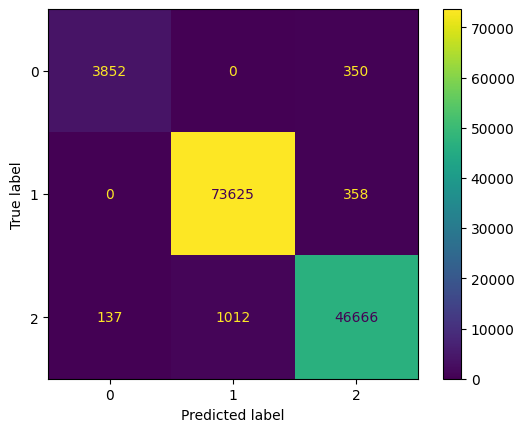

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

pred = cb.predict(X_val).astype(int).flatten()

cm = confusion_matrix(y_val, pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()


In [12]:
final_model = CatBoostClassifier(
    iterations=300,
    depth=8,
    learning_rate=0.08,
    loss_function='MultiClass',
    verbose=100
)

final_model.fit(X, y_encoded)


0:	learn: 0.9536347	total: 1.07s	remaining: 5m 20s
100:	learn: 0.0621710	total: 1m 44s	remaining: 3m 25s
200:	learn: 0.0589840	total: 3m 24s	remaining: 1m 40s
299:	learn: 0.0569529	total: 5m 3s	remaining: 0us


CatBoostClassifier(depth=8, iterations=300, learning_rate=0.08, loss_function='MultiClass', verbose=100)

In [13]:
final_preds = final_model.predict(X_test).astype(int).flatten()

final_labels = target_encoder.inverse_transform(final_preds)


In [14]:
submission = pd.DataFrame({
    "id": test_ids,
    "Irrigation_Need": final_labels
})

submission.to_csv("submission.csv", index=False)

print("submission.csv created!")


submission.csv created!


In [15]:
files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>